# Random Forest Regression
A random forest is an ensemble learning method that combines the predictions from multiple decision trees to produce a more accurate and stable prediction. 

It is a type of supervised learning algorithm that can be used for both classification and regression tasks.

In regression task we can use Random Forest Regression technique for predicting numerical values. It predicts continuous values by averaging the results of multiple decision trees.

Random Forest Regression works by creating multiple of decision trees each trained on a random subset of the data.

The process begins with Bootstrap sampling where random rows of data are selected with replacement to form different training datasets for each tree.

After this we do feature sampling where only a random subset of features is used to build each tree ensuring diversity in the models.

After the trees are trained each tree make a prediction and the final prediction for regression tasks is the average of all the individual tree predictions and this process is called as Aggregation.

This approach is beneficial because individual decision trees may have high variance and are prone to overfitting especially with complex data.

However by averaging the predictions from multiple decision trees Random Forest minimizes this variance leading to more accurate and stable predictions and hence improving generalization of model.

# Implementing Random Forest Regression in Python
data in dataset - bike_rentals 


In [172]:
# necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load

In [175]:
# import dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\bike_rentals.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


# explore

In [178]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [180]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [182]:
#df.isnull().sum()

In [184]:
df.drop(["datetime"], axis=1, inplace=True)

Text(0, 0.5, 'frequency')

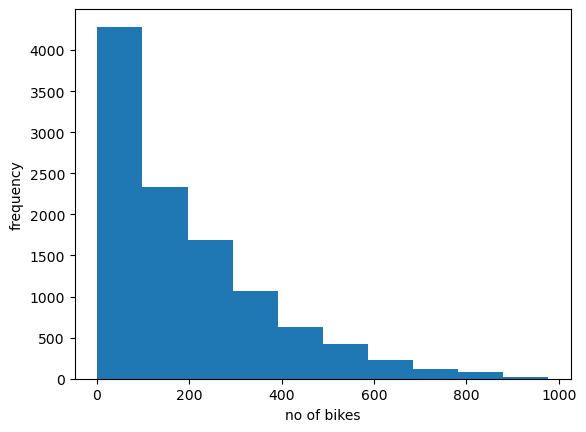

In [186]:
plt.hist(df['count'])
plt.xlabel('no of bikes')
plt.ylabel('frequency')

# split

In [189]:
X = df.iloc[:, :-1] # all rows ,  all cols except the last col
y = df.iloc[:, -1] # all rows ,  the last col

# train

In [192]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)
print(X_train.shape)
print(y_train.shape)

(8164, 10)
(8164,)


# baseline

In [195]:
y_pred_baseline = [y_train.mean()] * len(y_train)
print(y_pred_baseline[:5])

[191.33978441940226, 191.33978441940226, 191.33978441940226, 191.33978441940226, 191.33978441940226]


# predict 

In [198]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

model = rf.fit(X_train,y_train)

y_pred = model.predict(X_test)
print(y_pred)

[127.36  12.98 161.97 ...  26.02 126.65  82.57]


# evaluate

In [200]:
from sklearn.metrics import mean_squared_error

mae_baseline = mean_squared_error(y_train,y_pred_baseline)
print("mae_baseline:", mae_baseline)

mae = mean_squared_error(y_test,y_pred)
print("mae:", mae)

mae_baseline: 32808.831876288656
mae: 10.186936994856717


# example 2
data in dataset - Position_Salaries

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# load

In [364]:
# import dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\Position_Salaries.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [366]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


# data preparation
Extracting Features: It extracts the features from the DataFrame and stores them in a variable named X.

Extracting Target Variable: It extracts the target variable from the DataFrame and stores it in a variable named y.

In [369]:
# Select feature (independent variable) and target (dependent variable)
X = df[['Level']].values  # 2D array for model compatibility
y = df['Salary'].values   # Target variable

# Random Forest Regressor Model
The code processes categorical data by encoding it numerically, combines the processed data with numerical data, and trains a Random Forest Regression model using the prepared data.

In [413]:
# Create and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=10, random_state=0,oob_score=True)
model.fit(X, y)

RandomForestRegressor(n_estimators=10, oob_score=True, random_state=0)

RandomForestRegressor: It builds multiple decision trees and combines their predictions.

n_estimators=100: Defines the number of decision trees in the Random Forest (10 trees in this case).

random_state=42: Ensures the randomness in model training is controlled for reproducibility.

# Make predictions

In [415]:
# Predict salary for existing levels
y_pred = model.predict(X)

# Predict salary for a new level (example: Level 6.5)
new_level = np.array([[6.5]])
predicted_salary = model.predict(new_level)
print(f"Predicted salary for Level 6.5: {predicted_salary[0]}")


Predicted salary for Level 6.5: 167000.0


#  Visualization

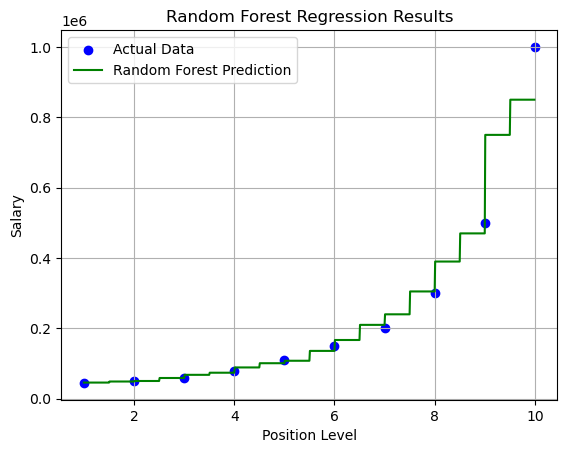

In [417]:
# Generate a smoother curve
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
y_grid_pred = model.predict(X_grid)

# Plot actual data points
plt.scatter(X, y, color='blue', label="Actual Data")

# Plot the Random Forest prediction curve
plt.plot(X_grid, y_grid_pred, color='green', label="Random Forest Prediction")

# Customize the plot
plt.title("Random Forest Regression Results")
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

#  Evaluate the Model Performance

In [421]:
oob_score = model.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

# Calculate errors
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

r2 = r2_score(y, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.6819214296245728
Mean Absolute Error (MAE): 22700.0
Mean Squared Error (MSE): 2384100000.0
Root Mean Squared Error (RMSE): 48827.24649209701
R-squared: 0.9671801245316117


# Visualizing a Single Decision Tree from the Random Forest Model

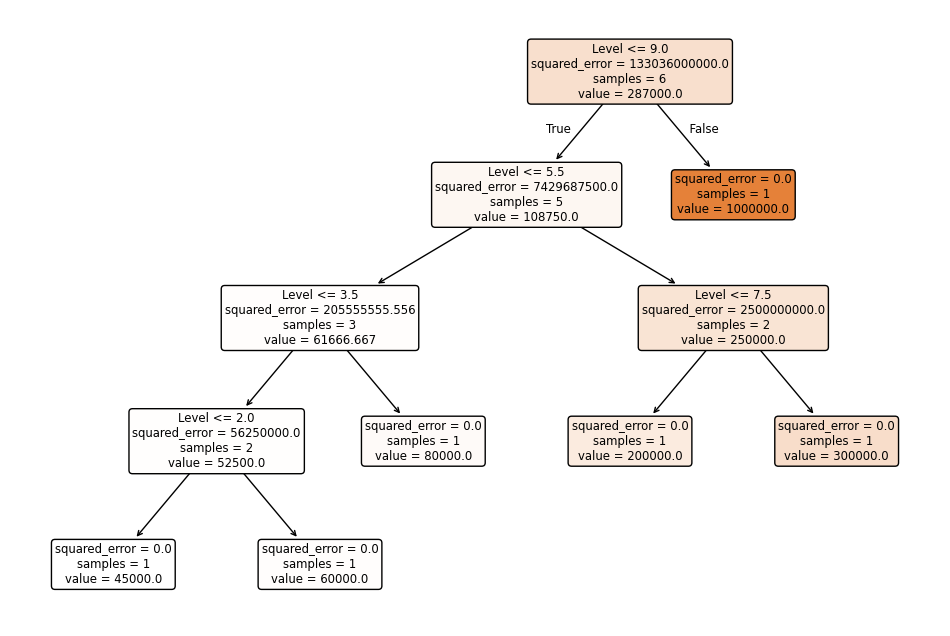

In [423]:
from sklearn.tree import export_text, plot_tree
# Select one tree from the trained Random Forest model
tree_index = 0  # Selecting the first tree
single_tree = model.estimators_[tree_index]  # Extract the first decision tree

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(single_tree, feature_names=['Level'], filled=True, rounded=True)
plt.show()

# Example 3

# Task: Train a Random Forest Regressor to predict house prices.
📌 Boston Housing Prices

🔹 Description: Predicts house prices based on features like crime rate, property tax, and number of rooms.

## note:
The Boston Housing dataset is a classic dataset for regression tasks, but sklearn.datasets.load_boston() has been deprecated due to ethical concerns regarding some of its features. 

However, you can still practice with it by downloading from Kaggle or using alternative datasets.

## Data description
The Boston data frame has 506 rows and 14 columns.

This data frame contains the following columns:

crim:
per capita crime rate by town.

zn:
proportion of residential land zoned for lots over 25,000 sq.ft.

indus:
proportion of non-retail business acres per town.

chas:
Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

nox:
nitrogen oxides concentration (parts per 10 million).

rm:
average number of rooms per dwelling.

age:
proportion of owner-occupied units built prior to 1940.

dis:
weighted mean of distances to five Boston employment centres.

rad:
index of accessibility to radial highways.

tax:
full-value property-tax rate per $10,000.

ptratio:
pupil-teacher ratio by town.

b:
1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.

lstat:
lower status of the population (percent).

medv:
median value of owner-occupied homes in $1000s.

In [237]:
from sklearn.datasets import fetch_openml
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# Load dataset from OpenML
boston = fetch_openml(name="boston", as_frame=True)
df = boston.frame  # Convert to DataFrame

# Show first few rows
print(df.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


# Train a Random Forest Regressor

In [218]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define Features (X) and Target (y)
X = df.drop(columns=["MEDV"])  # MEDV (Median House Value) is the target
y = df["MEDV"]

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

(404, 13)
(404,)
Mean Absolute Error: 2.0395392156862746
R² Score: 0.8922527442109116


##  Enhancing Boston Housing Price Prediction with Advanced Techniques
To improve our Random Forest model, let's implement the following:
Feature Engineering: Add interaction terms & normalize features.

Try Different Models: Compare performance with XGBoost & Gradient Boosting.

Hyperparameter Tuning: Use GridSearchCV to optimize Random Forest.



##  Feature Engineering: Adding Interaction Terms & Normalization
Feature engineering can improve model accuracy by making patterns more apparent.

### Add Interaction Terms
Interaction terms help capture non-linear relationships between features.

In [222]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Select numerical features (excluding the target variable "MEDV")
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

# Add polynomial interaction terms (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)



(404, 104)
(404,)


In [224]:
print("Missing values in y_train:", pd.isnull(y_train).sum())

Missing values in y_train: 0


##  Compare Performance of Different Models
We'll train Random Forest, XGBoost, and Gradient Boosting and compare their performance. 

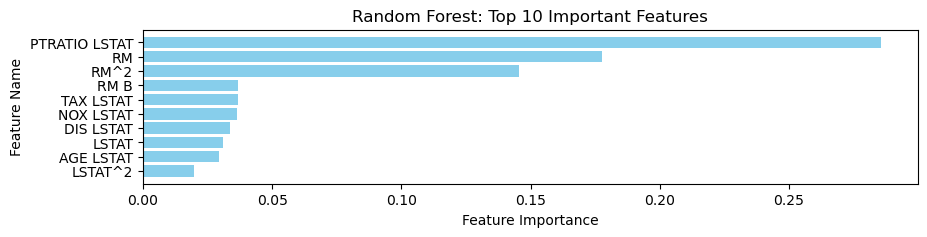

 Random Forest:
 Mean Absolute Error: 1.97
 R² Score: 0.8869



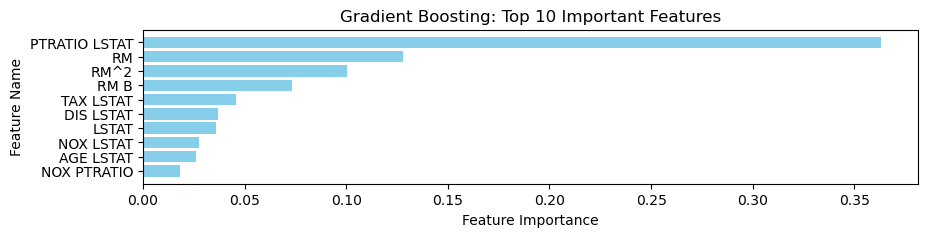

 Gradient Boosting:
 Mean Absolute Error: 1.95
 R² Score: 0.8909



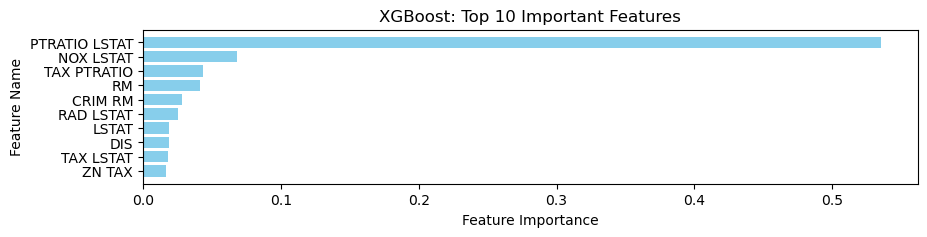

 XGBoost:
 Mean Absolute Error: 2.03
 R² Score: 0.8842



In [231]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel

# Train and Evaluate Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    
    # Get feature importance scores
    feature_importances = model.feature_importances_
    feature_names = poly.get_feature_names_out()  # Get feature names from PolynomialFeatures
    
    # Sort features by importance
    feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
    feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(10, 2))
    plt.barh(feature_importance_df["Feature"][:10], feature_importance_df["Importance"][:10], color="skyblue")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"{name}: Top 10 Important Features")
    plt.gca().invert_yaxis()
    plt.show()

    y_pred = model.predict(X_test)  # Predict on test data
    
    # Evaluate model
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f" {name}:")
    print(f" Mean Absolute Error: {mae:.2f}")
    print(f" R² Score: {r2:.4f}\n")

# example 4
📌 Stock Market Prices 📈
🔹 Where to Find: Use Yahoo Finance API

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# load data

In [24]:
# Fetch historical stock data for Apple (AAPL)
df = yf.download("AAPL", start="2021-01-01", end="2025-03-15")

# Display the first few rows
print(df.tail())
df.info()

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-03-10  227.479996  236.160004  224.220001  235.539993  72071200
2025-03-11  220.839996  225.839996  217.449997  223.809998  76137400
2025-03-12  216.979996  221.750000  214.910004  220.139999  62547500
2025-03-13  209.679993  216.839996  208.419998  215.949997  61368300
2025-03-14  213.490005  213.949997  209.580002  211.250000  60060200
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1054 entries, 2021-01-04 to 2025-03-14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1054 non-null   float64
 1   (High, AAPL)    1054 non-null   float64
 2   (Low, AAPL)     1054 non-null   float64
 3   (Open, AAPL)    1054 non-null   float64
 4   (Volume, AAPL)  1054 non-null   int64  
dtypes: f

# Visualize Stock Prices
closing price over time

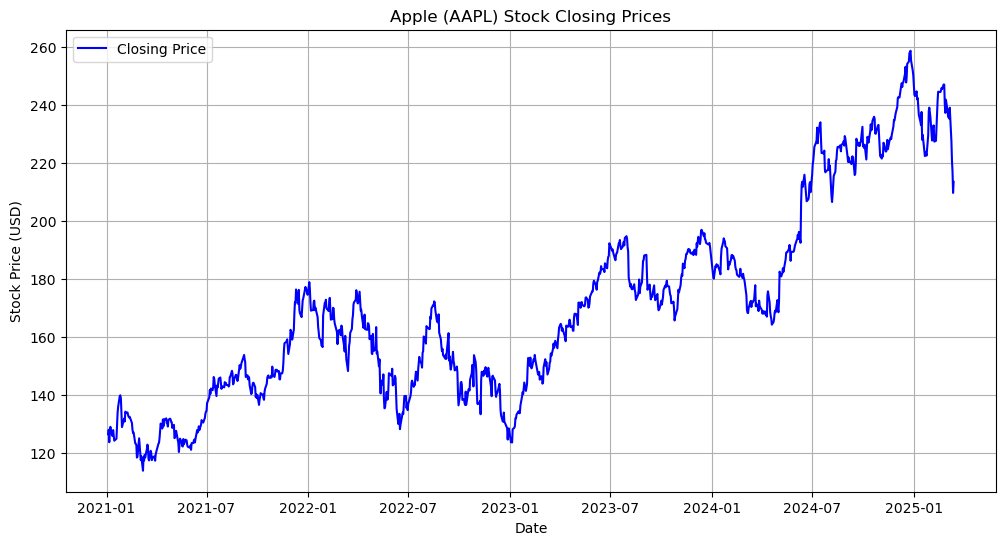

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Closing Price", color="blue")

plt.title("Apple (AAPL) Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid()
plt.show()

# Train a Random Forest Regressor on Stock Data
let's predict future stock prices using a Random Forest Regressor.

# Step 1: Prepare the Data

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# Use only numerical values: Date as an integer
"""
This calculates the difference between each date and 1970-01-01.
pd.Timedelta('1D') represents one day.
// performs integer division, converting the TimedeltaIndex into plain integers.
"""
df["Date_Int"] = (df.index - pd.Timestamp("1970-01-01")) // pd.Timedelta('1D')
df.head()

# Define Features (X) and Target Variable (y)
X = df[["Date_Int"]].values  # Convert dates to numerical format
y = df["Close"].values.squeeze()      # Predicting closing prices

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('y_train',y_train.shape)
print('y_test',y_test.shape)
print('X_train',X_train.shape)
print('X_test',X_test.shape)

y_train (843,)
y_test (211,)
X_train (843, 1)
X_test (211, 1)


# Step 2: Train Random Forest Model

In [48]:
# Initialize and Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Step 3: Make Predictions

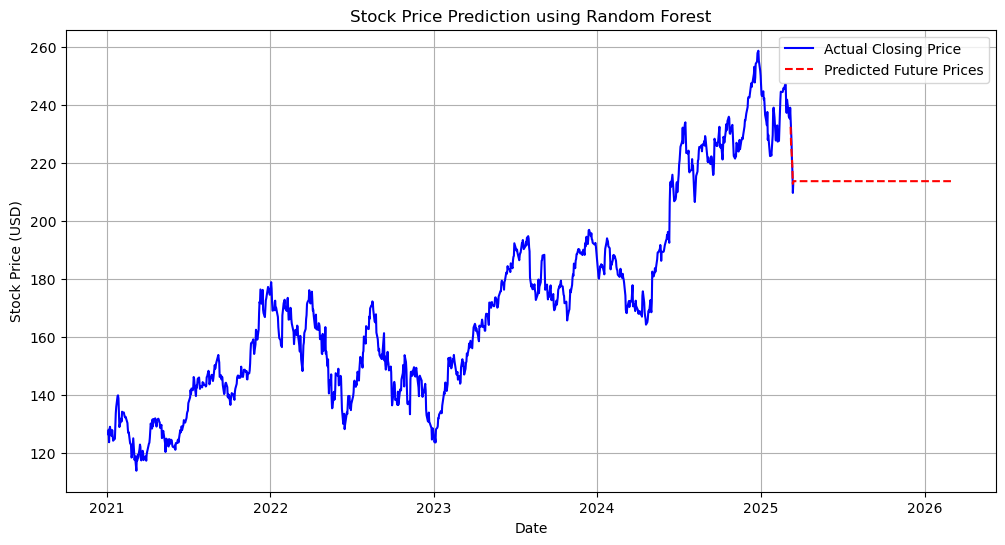

In [55]:
import numpy as np

# Generate future dates (next 30 days)
future_dates = np.array(range(X_test.max() + 1, X_test.max() + 366)).reshape(-1, 1)

# Predict future stock prices
future_prices = rf_model.predict(future_dates)

# Convert numerical dates back to actual dates
future_dates_actual = pd.to_datetime(future_dates.flatten(), origin="1970-01-01", unit="D")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Actual Closing Price", color="blue")
plt.plot(future_dates_actual, future_prices, label="Predicted Future Prices", linestyle="dashed", color="red")

plt.title("Stock Price Prediction using Random Forest")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid()
plt.show()

🔹 Why Are Predictions Inaccurate?

1️⃣ Stock markets are closed on weekends and holidays → The model predicts prices for non-existent trading days.

2️⃣ Random Forest is not the best for time series forecasting → It does not capture trends and seasonality well.

3️⃣ The model does not consider external factors (e.g., market news, economic events, interest rates).

# Applications of Random Forest Regression
The Random forest regression has a wide range of real-world problems including:

Predicting continuous numerical values: Predicting house prices, stock prices or customer lifetime value.

Identifying risk factors: Detecting risk factors for diseases, financial crises or other negative events.

Handling high-dimensional data: Analyzing datasets with a large number of input features.

Capturing complex relationships: Modeling complex relationships between input features and the target variable.

# Advantages of Random Forest Regression

Handles Non-Linearity: It can capture complex, non-linear relationships in the data that other models might miss.

Reduces Overfitting: By combining multiple decision trees and averaging predictions it reduces the risk of overfitting compared to a single decision tree.

Robust to Outliers: Random Forest is less sensitive to outliers as it aggregates the predictions from multiple trees.

Works Well with Large Datasets: It can efficiently handle large datasets and high-dimensional data without a significant loss in performance.

Handles Missing Data: Random Forest can handle missing values by using surrogate splits and maintaining high accuracy even with incomplete data.

No Need for Feature Scaling: Unlike many other algorithms Random Forest does not require normalization or scaling of the data.

# Disadvantages of Random Forest Regression
Complexity: It can be computationally expensive and slow to train especially with a large number of trees and high-dimensional data.

Less Interpretability: Since it uses many trees it can be harder to interpret compared to simpler models like linear regression or decision trees.

Memory Intensive: Storing multiple decision trees for large datasets require significant memory resources.

Overfitting on Noisy Data: While Random Forest reduces overfitting, it can still overfit if the data is highly noisy, especially with a large number of trees.

Sensitive to Imbalanced Data: It may perform poorly if the dataset is highly imbalanced like one class is significantly more frequent than another.

Difficulty in Real-Time Predictions: Due to its complexity it may not be suitable for real-time predictions especially with a large number of trees.


Random Forest Regression has become a powerful tool for continuous prediction tasks with advantages over traditional decision trees. Its capability to handle high-dimensional data, capture complex relationships and reduce overfitting has made it a popular choice for a variety of applications.

Python’s scikit-learn library enables the implementation of Random Forest Regression models possible.